# Data Pre-processing Notebook

This notebook contains the data pre-processing steps before model training. It includes:

- Data loading and exploration
- Null value analysis  
- Feature engineering
- Data transformation and cleaning
- Export of processed data

First, run seq_extract.py to extract protein sequences for raw_data.tsv:
```
python datasets/seq_extract.py
```
This will create protein_seq.tsv with the extracted sequences from UniProt IDs.

In [4]:
import pandas as pd
import numpy as np
import re
from basic_statictical.historams import histogram
from basic_statictical.seq_distribution import sequence_length_distribution
from basic_statictical.correlations import pearson_correlation_heatmap, spearman_correlation_heatmap
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

seq_extracted = "protein_seq.tsv"
dataset = "protein_dataset.tsv"

In [2]:
# Remove duplicates
df = pd.read_csv(seq_extracted, sep="\t")
total_rows = len(df)

df_no_duplicates = df.drop_duplicates(keep="last")
rows_after_dedup = len(df_no_duplicates)
duplicates_removed = total_rows - rows_after_dedup

df_no_duplicates.to_csv(dataset, sep="\t", index=False)

print(f"Total rows before deduplication: {total_rows}")
print(f"Total rows after deduplication: {rows_after_dedup}")
print(f"Number of duplicate rows removed: {duplicates_removed}")

Total rows before deduplication: 32280
Total rows after deduplication: 31108
Number of duplicate rows removed: 1172


In [3]:
df = pd.read_csv(dataset, sep="\t")
total_rows = len(df)

df_filtered = df.dropna(subset=["Protein_Sequence"])
df_filtered = df_filtered[df_filtered["Protein_Sequence"].str.strip() != ""]

filtered_rows = len(df_filtered)
removed_rows = total_rows - filtered_rows

df_filtered.to_csv(dataset, sep="\t", index=False)

print(f"Total rows in original file: {total_rows}")
print(f"Rows removed (no sequence): {removed_rows}")
print(f"Rows remaining: {filtered_rows}")
print(f"Filtered data saved to {dataset}")

Total rows in original file: 31108
Rows removed (no sequence): 2634
Rows remaining: 28474
Filtered data saved to protein_dataset.tsv


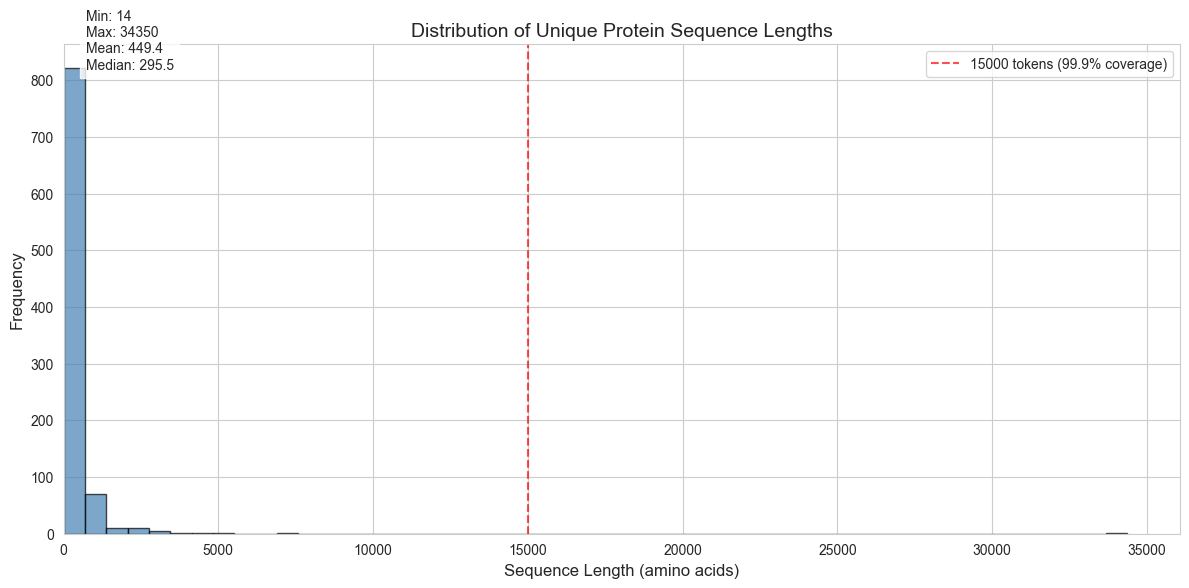

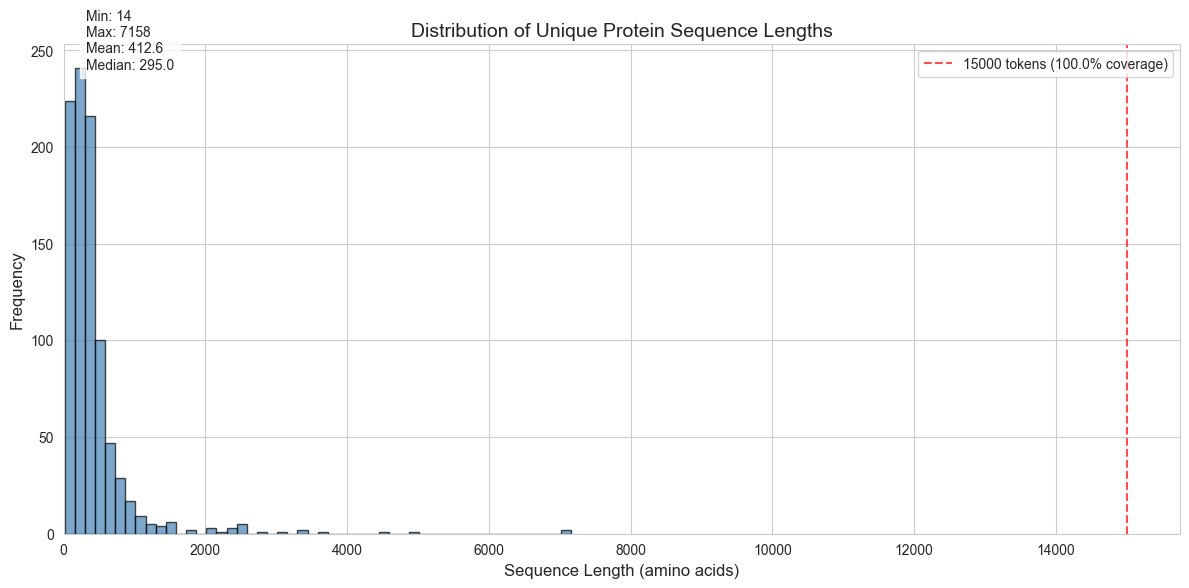

Total sequences: 28475
Sequences within length limit (15000): 28457
Sequences removed: 18 (0.06%)

Unique sequences before filtering: 923
Unique sequences after filtering: 922
Unique sequences removed: 1 (0.11%)


In [4]:
max_length = 15000
sequence_length_distribution(dataset, max_length)

df = pd.read_csv(dataset, sep='\t', header=None)

sequence_col = df.iloc[:, -1]
sequence_lengths = sequence_col.str.len()
filtered_df = df[sequence_lengths <= max_length]

filtered_df.to_csv(dataset, sep='\t', header=False, index=False)

sequence_length_distribution(dataset, max_length)

total_sequences = len(df)
filtered_sequences = len(filtered_df)
removed_sequences = total_sequences - filtered_sequences

unique_sequences_before = sequence_col.nunique()
unique_sequences_after = filtered_df.iloc[:, -1].nunique()
unique_sequences_removed = unique_sequences_before - unique_sequences_after

print(f"Total sequences: {total_sequences}")
print(f"Sequences within length limit ({max_length}): {filtered_sequences}")
print(f"Sequences removed: {removed_sequences} ({removed_sequences/total_sequences*100:.2f}%)")

print(f"\nUnique sequences before filtering: {unique_sequences_before}")
print(f"Unique sequences after filtering: {unique_sequences_after}")
print(f"Unique sequences removed: {unique_sequences_removed} ({unique_sequences_removed/unique_sequences_before*100:.2f}%)")


In [5]:
df = pd.read_csv(dataset, sep='\t')

found = False
for idx, row in df.iterrows():
    if row['SEC_STR'] == '-4.38':
        df.at[idx, 'SEC_STR'] = "Coil"
        found = True

if found:
    df.to_csv(dataset, sep='\t', index=False)
    print("File saved with the corrected SEC_STR value.")
else:
    print("No entry found with SEC_STR value = -4.38")

File saved with the corrected SEC_STR value.


In [6]:
COIL = 0
HELIX = 1
SHEET = 2
TURN = 3


def encode_secondary_structure(structure_text):
    """
    Encode secondary structure information as a count vector.
    Format: [coil_count, helix_count, sheet_count, turn_count]
    """
    if not structure_text or structure_text == "-":
        return [0, 0, 0, 0]

    counts = [0, 0, 0, 0]
    structures = [s.strip() for s in structure_text.split(",")]

    for structure in structures:
        if "Coil" in structure:
            counts[COIL] += 1
        elif "Helix" in structure:
            counts[HELIX] += 1
        elif "Sheet" in structure:
            counts[SHEET] += 1
        elif "Turn" in structure:
            counts[TURN] += 1

    return counts


df = pd.read_csv(dataset, sep="\t")
df["SEC_STR_ENCODED"] = df["SEC_STR"].apply(encode_secondary_structure)
df.to_csv(dataset, sep="\t", index=False)

print("\nSecondary Structure Types and Their Encodings:")
print("-" * 50)
print(f"{'Secondary Structure':<25} {'Count-Based Encoding'}")
print("-" * 50)

examples = [
    "Coil",
    "Helix",
    "Sheet",
    "Turn",
    "Helix, Sheet",
    "Helix, Turn, Turn",
    "-",
]

for example in examples:
    encoding = encode_secondary_structure(example)
    print(f"{example:<25} {encoding}")


Secondary Structure Types and Their Encodings:
--------------------------------------------------
Secondary Structure       Count-Based Encoding
--------------------------------------------------
Coil                      [1, 0, 0, 0]
Helix                     [0, 1, 0, 0]
Sheet                     [0, 0, 1, 0]
Turn                      [0, 0, 0, 1]
Helix, Sheet              [0, 1, 1, 0]
Helix, Turn, Turn         [0, 1, 0, 2]
-                         [0, 0, 0, 0]


In [7]:
df = pd.read_csv(dataset, sep="\t")

def clean_value(value):
    if isinstance(value, str):
        if value.strip() == "-":
            return value

        if "(" in value:
            return value.split("(")[0].strip()
    return value


df_clean = df.copy()

columns_to_clean = []
for col in df_clean.columns:
    if df_clean[col].astype(str).str.contains(r"\(.*\)").any():
        columns_to_clean.append(col)

print(
    f"Found {len(columns_to_clean)} columns with bracket values: {columns_to_clean}"
)

for col in columns_to_clean:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].apply(clean_value)
        
        if col not in ["STATE", "REVERSIBILITY", "SEC_STR", "UniProt_ID", "PDB_wild"]:
            df_clean[col] = df_clean[col].apply(
                lambda x: pd.to_numeric(x, errors="coerce") if x != "-" else x
            )

print("\nCleaned values:")
for col in df.columns:
    orig_values = df[col].astype(str).str.contains(r"\(\d+\.?\d*\)")
    if orig_values.any():
        idx = orig_values.idxmax()
        print(
            f"Column {col} - Original: {df[col][idx]} → Cleaned: {df_clean[col][idx]}"
        )

df_clean = df_clean.fillna("-")
df_clean.to_csv(dataset, sep="\t", index=False, na_rep="-")
print(f"\nCleaned dataset saved to {dataset}")

Found 12 columns with bracket values: ['Tm_(C)', '∆Tm_(C)', '∆H_(kcal/mol)', '∆Cp_(kcal/mol)', '∆HvH_(kcal/mol)', '∆G_(kcal/mol)', '∆∆G_(kcal/mol)', 'm_(kcal/mol/M)', 'Cm_(M)', '∆G_H2O_(kcal/mol)', '∆∆G_H2O_(kcal/mol)', 'REVERSIBILITY']

Cleaned values:
Column Tm_(C) - Original: 58.7(0.7) → Cleaned: 58.7
Column ∆Tm_(C) - Original: 61.9 (0.4) → Cleaned: 61.9
Column ∆H_(kcal/mol) - Original: 15.8 (0.29) → Cleaned: 15.8
Column ∆Cp_(kcal/mol) - Original: -1.44 (0.24) → Cleaned: -1.44
Column ∆HvH_(kcal/mol) - Original: 104 (0.49) → Cleaned: 104
Column ∆G_(kcal/mol) - Original: 9.81 (0.18) → Cleaned: 9.81
Column ∆∆G_(kcal/mol) - Original: -0.76 (0.9) → Cleaned: -0.76
Column m_(kcal/mol/M) - Original: 1.7 (0.2) → Cleaned: 1.7
Column Cm_(M) - Original: 1.86(0.01) → Cleaned: 1.86
Column ∆G_H2O_(kcal/mol) - Original: 2.95 (0.19) → Cleaned: 2.95
Column ∆∆G_H2O_(kcal/mol) - Original: 0.62 (0.06) → Cleaned: 0.62
Column REVERSIBILITY - Original: yes(0.94) → Cleaned: yes

Cleaned dataset saved to pro

In [8]:
df = pd.read_csv(dataset, sep="\t", na_values=["-"])

total_rows = len(df)

null_counts = df.isna().sum()
non_null_counts = df.notna().sum()

null_percentages = (null_counts / total_rows * 100).round(2)
non_null_percentages = (non_null_counts / total_rows * 100).round(2)

results = pd.DataFrame(
    {
        "Null Count": null_counts,
        "Null %": null_percentages,
        "Non-Null Count": non_null_counts,
        "Non-Null %": non_null_percentages,
    },
    index=df.columns,
)

print(results)

                    Null Count  Null %  Non-Null Count  Non-Null %
UniProt_ID                   0    0.00           28456      100.00
PDB_wild                  1716    6.03           26740       93.97
SEC_STR                  12023   42.25           16433       57.75
ASA                      14299   50.25           14157       49.75
pH                          69    0.24           28387       99.76
T_(C)                    14413   50.65           14043       49.35
Tm_(C)                   14436   50.73           14020       49.27
∆Tm_(C)                  22069   77.55            6387       22.45
∆H_(kcal/mol)            23507   82.61            4949       17.39
∆Cp_(kcal/mol)           25391   89.23            3065       10.77
∆HvH_(kcal/mol)          23364   82.11            5092       17.89
∆G_(kcal/mol)            27074   95.14            1382        4.86
∆∆G_(kcal/mol)           25640   90.10            2816        9.90
m_(kcal/mol/M)           21303   74.86            7153       2

In [9]:
df = pd.read_csv(dataset, sep='\t')

def map_reversibility(value):
    if isinstance(value, str):
        if value.lower() == "yes":
            return 1.0
        elif value.lower() == "no":
            return 0.0
        elif value.lower() in ["unknown", "unknownnouwn"] :
            return -1.0
        elif value.lower() == "partially reversible":
            return 0.5
        elif value.lower() == "yes, 90%":
            return 0.9
        elif value.lower() == "70% reversible":
            return 0.7
        elif value.lower() == "> 90%":
            return 0.95
    return value

df['REVERSIBILITY'] = df['REVERSIBILITY'].apply(map_reversibility)

df.to_csv(dataset, sep='\t', index=False)
print("File saved with the updated REVERSIBILITY values.")

File saved with the updated REVERSIBILITY values.


Null handling

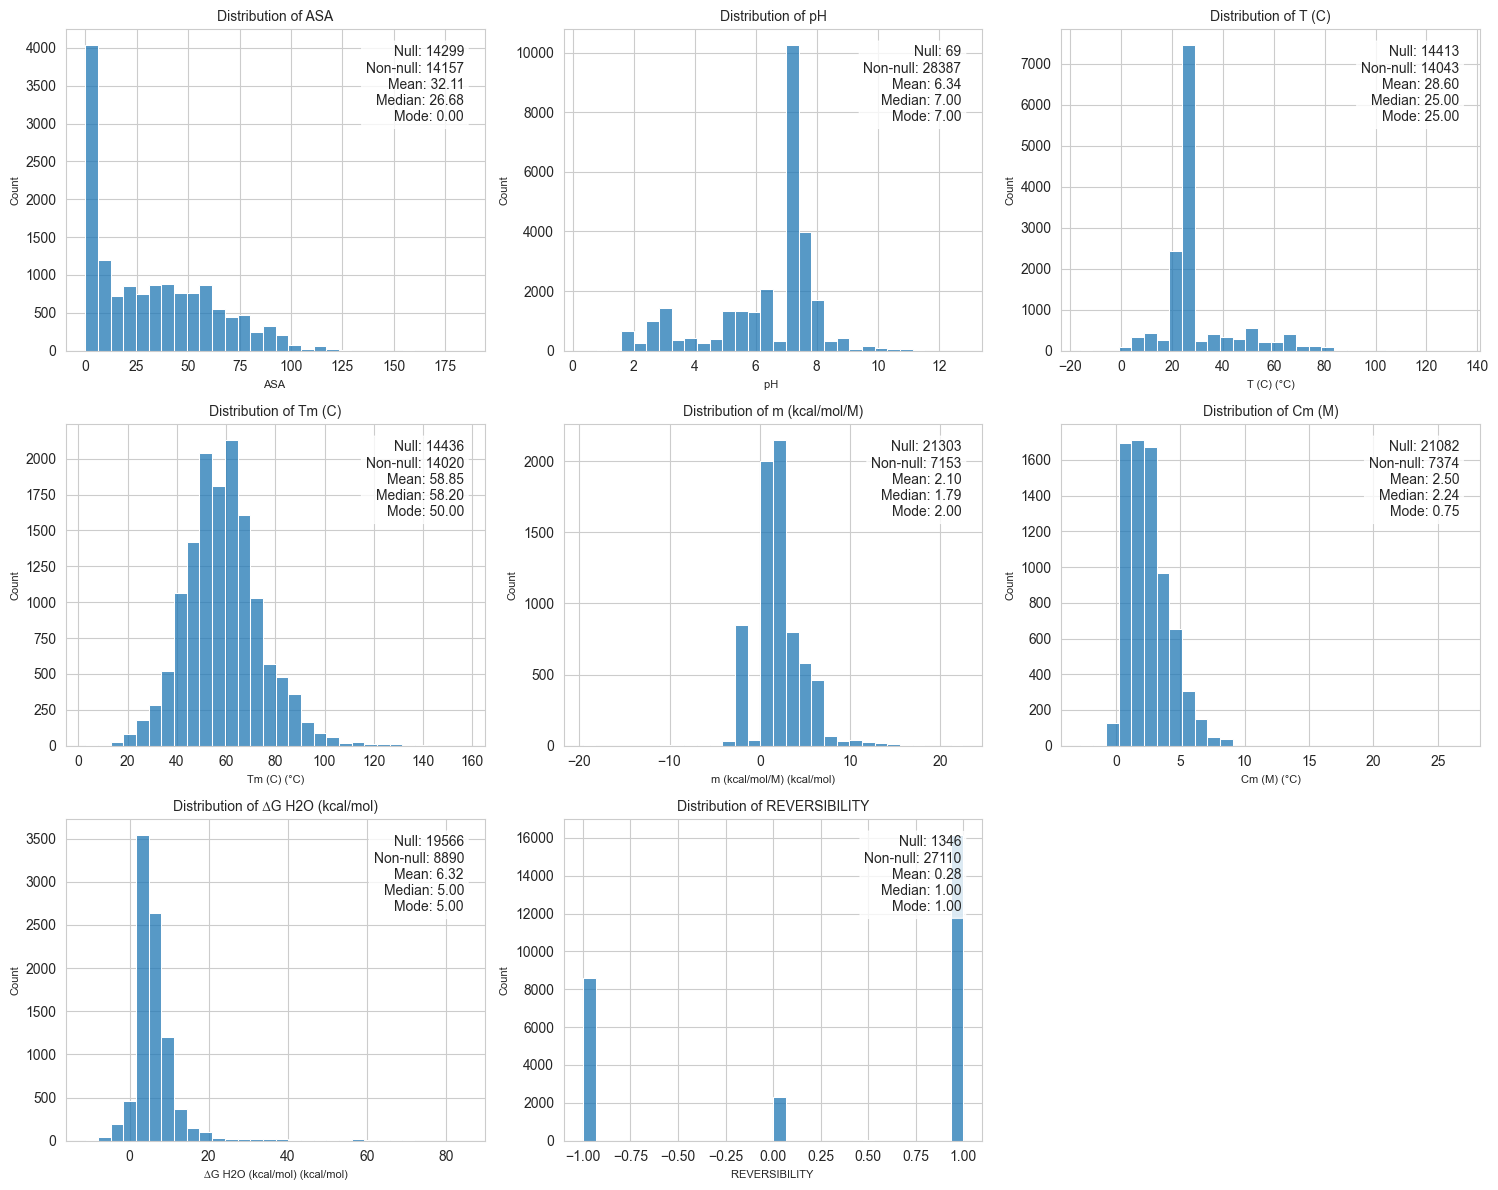

Null values have been handled successfully!


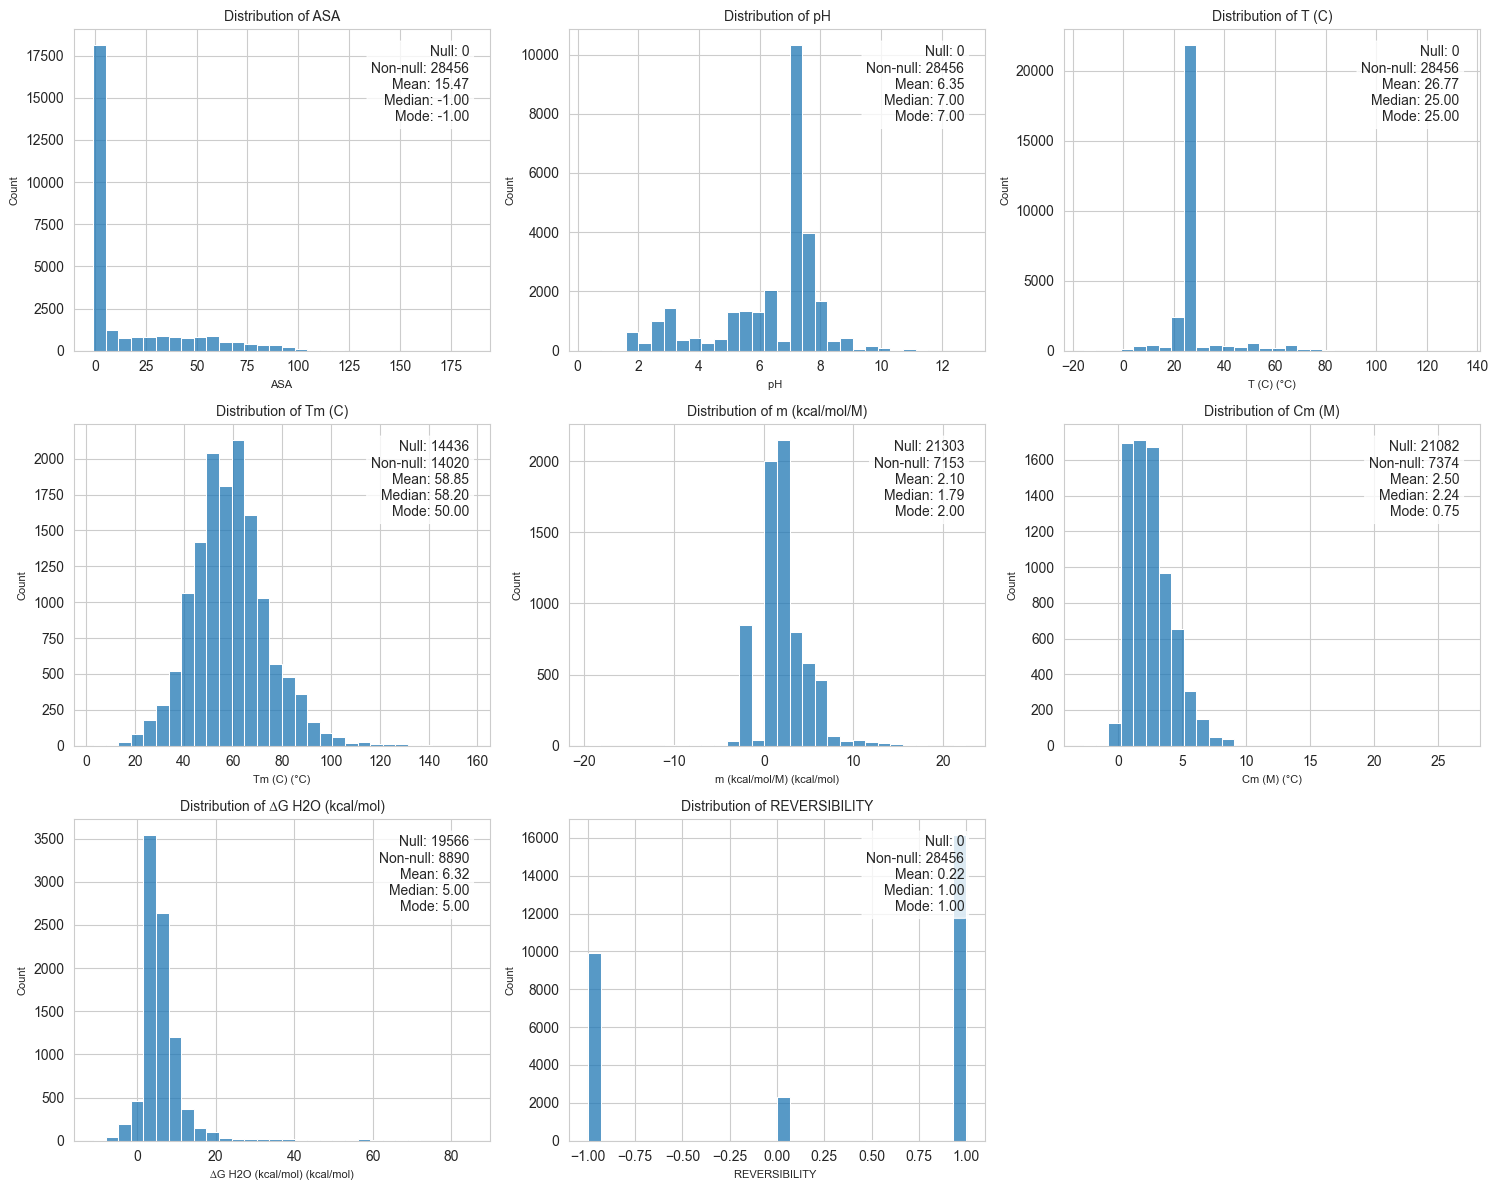

In [10]:
dataset = "protein_dataset.tsv"
histogram(dataset)

df = pd.read_csv(dataset, sep="\t")

df.replace("-", np.nan, inplace=True)

df["ASA"] = df["ASA"].fillna(-1)    # Flag
df["pH"] = df["pH"].fillna(7.0)    # Mode 
df["T_(C)"] = df["T_(C)"].fillna(25.0)    # Mode
df["REVERSIBILITY"] = df["REVERSIBILITY"].fillna(-1)    # Flag

df["ASA"] = df["ASA"].astype(float)
df["pH"] = df["pH"].astype(float)
df["T_(C)"] = df["T_(C)"].astype(float)
df["REVERSIBILITY"] = df["REVERSIBILITY"].astype(float)

df.to_csv(dataset, sep="\t", index=False)
print(f"Null values have been handled successfully!")
histogram(dataset)

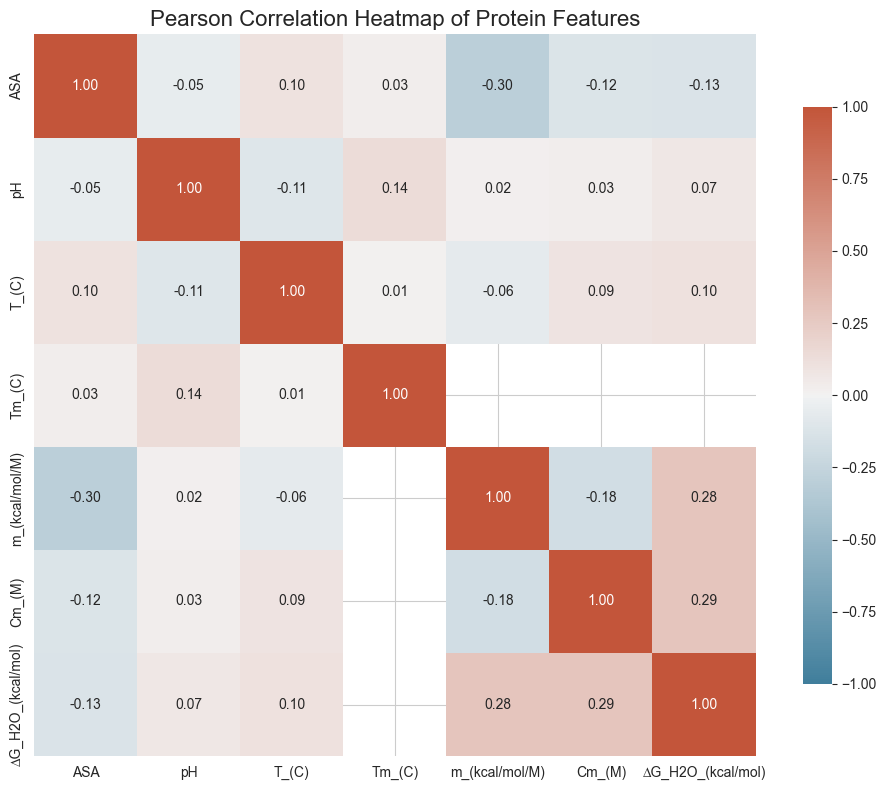

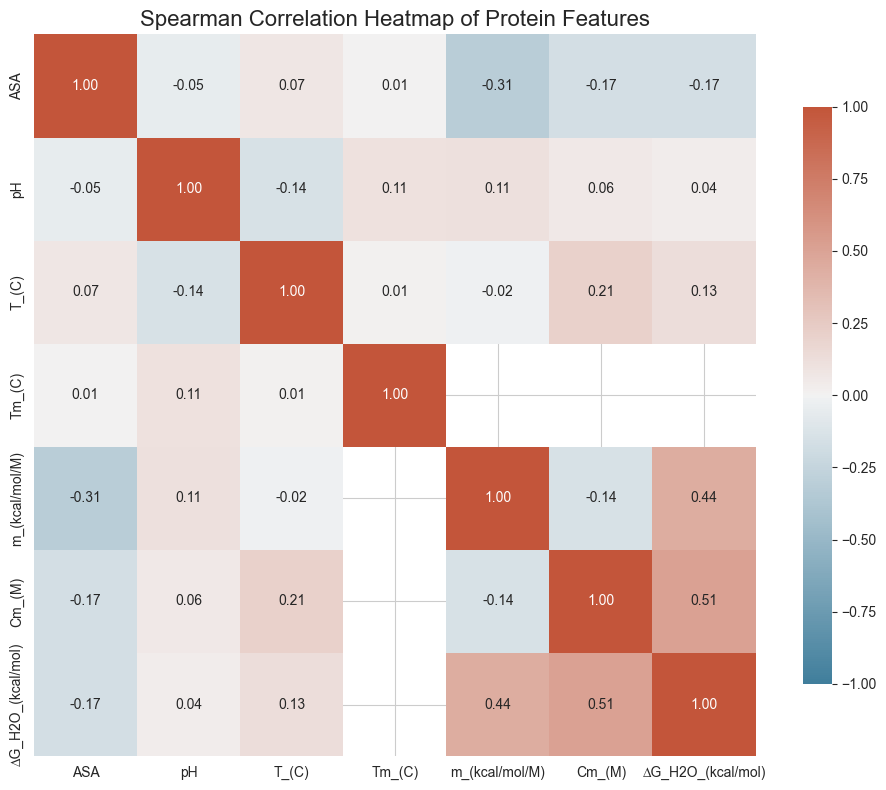

In [11]:
pearson_correlation_heatmap(dataset)
spearman_correlation_heatmap(dataset)

In [4]:
embeddings_file = "sequence_embeddings.csv"

df = pd.read_csv(dataset, sep="\t")
embeddings_df = pd.read_csv(embeddings_file)

embeddings_df["Embedding"] = embeddings_df["Embedding"].apply(
    lambda x: np.array([float(num) for num in re.findall(r"-?\d+\.?\d*e?[-+]?\d*", x)])
)

features = []
print(f"Processing {len(df)} protein records...")

for i, (_, row) in enumerate(df.iterrows()):
    if i % 10000 == 0:
        print(f"Processing record {i}/{len(df)}...")
    
    asa = row["ASA"]
    ph = row["pH"]
    temp = row["T_(C)"]
    
    tm = row["Tm_(C)"] if not pd.isna(row["Tm_(C)"]) else None
    m_value = row["m_(kcal/mol/M)"] if not pd.isna(row["m_(kcal/mol/M)"]) else None
    cm = row["Cm_(M)"] if not pd.isna(row["Cm_(M)"]) else None
    delta_g_h2o = row["∆G_H2O_(kcal/mol)"] if not pd.isna(row["∆G_H2O_(kcal/mol)"]) else None

    sec_str_encoded = eval(row["SEC_STR_ENCODED"])

    protein_seq = row["Protein_Sequence"]
    embedding_row = embeddings_df[embeddings_df["Protein_Sequence"] == protein_seq]

    if not embedding_row.empty:
        embedding = embedding_row["Embedding"].values[0]
    else:
        print(f"No embedding found for protein sequence: {protein_seq}")
        embedding = np.zeros(320)

    feature_vector = [asa, ph, temp] + sec_str_encoded + [tm, m_value, cm, delta_g_h2o] + embedding.tolist()
    features.append(feature_vector)

basic_columns = ["ASA", "pH", "T_(C)", "Coil", "Helix", "Sheet", "Turn"]
additional_columns = ["Tm_(C)", "m_(kcal/mol/M)", "Cm_(M)", "∆G_H2O_(kcal/mol)"]
embedding_columns = [f"embed_{i}" for i in range(320)]
all_columns = basic_columns + additional_columns + embedding_columns

features_df = pd.DataFrame(
    features,
    columns=all_columns,
)

features_df.to_csv("features.csv", index=False)
features_df.to_csv("features.csv.gz", index=False, compression="gzip")

print("Features shape:", features_df.shape)
print("\nFirst few rows (showing only non-embedding features):")
print(features_df[basic_columns + additional_columns].head())

Features shape: (28456, 331)

First few rows (showing only non-embedding features):
   ASA   pH  T_(C)  Coil  Helix  Sheet  Turn  Tm_(C)  m_(kcal/mol/M)  Cm_(M)  \
0 -1.0  7.0   25.0     0      0      0     0     NaN             1.7     NaN   
1 -1.0  7.0   25.0     0      0      0     0     NaN             1.8     NaN   
2 -1.0  7.0   25.0     0      0      0     0     NaN             1.4     NaN   
3 -1.0  7.0   25.0     0      0      0     0     NaN             1.0     NaN   
4 -1.0  7.0   25.0     0      0      0     0     NaN             1.3     NaN   

   ∆G_H2O_(kcal/mol)  
0                NaN  
1                NaN  
2                NaN  
3                NaN  
4                NaN  


Phase 2

In [6]:
df = pd.read_csv("features.csv")

features = [
    "ASA",
    "pH",
    "T_(C)",
    "Coil",
    "Helix",
    "Sheet",
    "Turn",
    "Tm_(C)",
    "m_(kcal/mol/M)",
    "Cm_(M)",
    "∆G_H2O_(kcal/mol)",
]

labels = [f"embed_{i}" for i in range(320)]

features_df = df[features].copy()
features_df = features_df.fillna(-1000)

labels_df = df[labels].copy()
labels_df = labels_df.fillna(0)

train_features, test_features, train_labels, test_labels = train_test_split(
    features_df, labels_df, test_size=0.1, random_state=42
)

train_features.to_csv("phase2/train/X_train.csv", index=False)
test_features.to_csv("phase2/test/X_test.csv", index=False)
train_labels.to_csv("phase2/train/y_train.csv", index=False)
train_labels.to_csv("phase2/train/y_train.csv.gz", index=False, compression="gzip")
test_labels.to_csv("phase2/test/y_test.csv", index=False)
test_labels.to_csv("phase2/test/y_test.csv.gz", index=False, compression="gzip")

print(
    "Features and labels split and saved to phase2/train and phase2/test directories"
)

Features and labels split and saved to phase2/train and phase2/test directories


In [3]:
df_train = pd.read_csv("phase2/train/X_train.csv")
df_test = pd.read_csv("phase2/test/X_test.csv")

df_train_normalized = df_train.copy()
df_test_normalized = df_test.copy()

numeric_cols = [
    "ASA",
    "pH",
    "T_(C)",
    "Tm_(C)",
    "m_(kcal/mol/M)",
    "Cm_(M)",
    "∆G_H2O_(kcal/mol)",
]

scaler = StandardScaler()

df_train_normalized = pd.DataFrame(
    scaler.fit_transform(df_train_normalized), columns=df_train.columns
)
df_test_normalized = pd.DataFrame(
    scaler.transform(df_test_normalized), columns=df_test.columns
)

df_train_normalized.to_csv("phase2/train/X_train_normalized.csv", index=False)
df_test_normalized.to_csv("phase2/test/X_test_normalized.csv", index=False)

print("Datasets normalized and saved successfully")

Datasets normalized and saved successfully
